### Generate dataset

In [2]:
from defect_gen import generate_dataset, show_samples

# Fixed training set: always 140 noise-only images
train_images_raw, _ = generate_dataset(n_samples=200, size=4, defect_rate=0.0, normal_range=(0.3, 0.5), defect_range=(0.95, 0.99), seed=7)


In [3]:
import numpy as np

# Flatten and scale
train_images_noise = np.array([img.flatten() * np.pi for img in train_images_raw])


In [4]:
# Image parameters
size = 16   # total pixels/qubits
vert_size = 4   # number of rows
hor_size  = size // vert_size  # number of columns = 4

In [5]:

def pixel_index(r, c):
    """Convert 2D (row, col) to flat 1D index."""
    return r * hor_size + c

## Choose the feature map U(x) to encode the data 

In [6]:
from qiskit.circuit.library import z_feature_map
from qiskit.circuit.library import zz_feature_map



# One qubit per data feature
num_qubits = len(train_images_noise[0])

# Data encoding
# Note that qiskit orders parameters alphabetically. We assign the parameter prefix "a" to ensure our data encoding goes to the first part of the circuit, the feature mapping.
#feature_map = z_feature_map(num_qubits, parameter_prefix="a")

feature_map = zz_feature_map(
    feature_dimension=num_qubits,
    reps=1,
    entanglement="linear",  # or "full" or "circular"
    parameter_prefix="a"
)

#feature_map = z_feature_map(num_qubits, parameter_prefix="a")



In [7]:
print(num_qubits)

16


## Our ansats for W(theta)

8
2+ qubit depth: 6


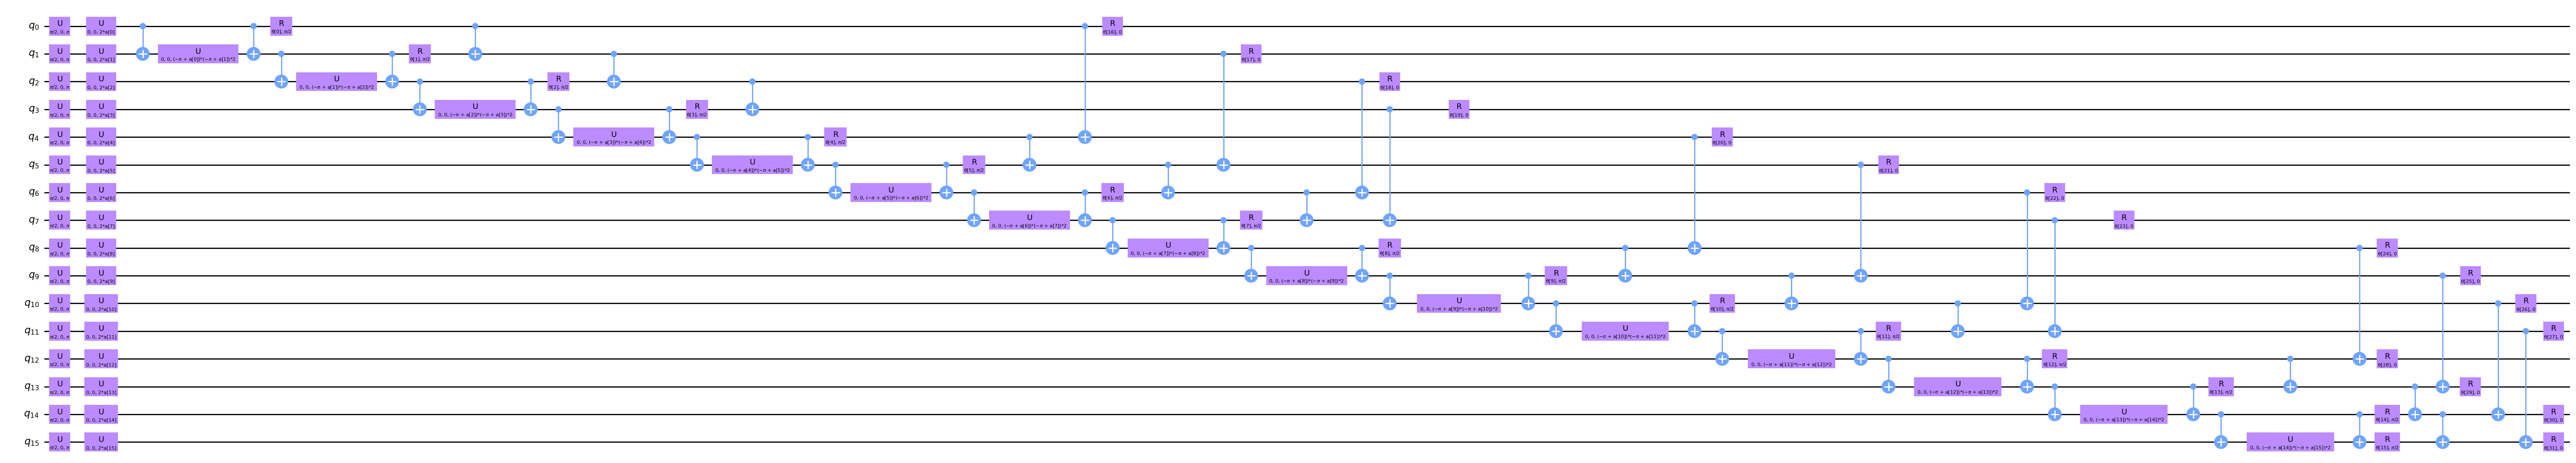

In [8]:
# Import the necessary packages
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(size)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * size)

# A first variational layer:
for i in range(size):
    qnn_circuit.ry(params[i], i)

# We creat correlations between all the qubits
# Horizontal neighbors (left-right correlations)
horizontal_cnots = [
    [pixel_index(r, c), pixel_index(r, c+1)]
    for r in range(vert_size)
    for c in range(hor_size - 1)
]

# Vertical neighbors (top-bottom correlations)
vertical_cnots = [
    [pixel_index(r, c), pixel_index(r+1, c)]
    for r in range(vert_size - 1)
    for c in range(hor_size)
]

qnn_cnot_list = horizontal_cnots + vertical_cnots

#qnn_cnot_list = [[0, 1], [1, 2], [2, 3], [4, 5], [5, 6], [6, 7]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(size):
    qnn_circuit.rx(params[size + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Combine the feature map and variational circuit
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

In [9]:
print(len(params))

32


### Compose the ansatz with feature map

In [10]:
# QNN ansatz
ansatz = qnn_circuit

full_circuit = QuantumCircuit(num_qubits)

# First upload + first ansatz layer
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Second upload + second ansatz layer
#full_circuit.compose(feature_map, range(num_qubits), inplace=True)
#full_circuit.compose(ansatz, range(num_qubits), inplace=True)

## Choose the observable

In [11]:
from qiskit.quantum_info import SparsePauliOp

# observable
observable = SparsePauliOp.from_sparse_list(
    [("Z", [q], 1) for q in range(num_qubits)],
    num_qubits=num_qubits
)


## Expectation values of the observables

In [12]:
from qiskit.primitives import BaseEstimatorV2
from qiskit.quantum_info.operators.base_operator import BaseOperator


def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

## Loss function 

In [13]:
def one_class_loss_weights(weight_params):
    predictions = forward(
        circuit=circuit,
        input_params=input_params,
        weight_params=weight_params,
        estimator=estimator,
        observable=observable,
    )
    variance = float(np.var(predictions))
    # push noise outputs toward -1
    mean_anchor = float((np.mean(predictions) - (-1.0))**2)
    cost = variance + 1 * mean_anchor
    
    objective_func_vals.append(cost)
    global iter
    if iter % 50 == 0:
        print(f"Iter: {iter}, loss: {cost}")
    iter += 1
    return cost

## import optimizer and set global variables for the cost function

In [14]:
from scipy.optimize import minimize
# Globals
circuit = full_circuit
observables = observable
# input_params = train_images_batch
# target = train_labels_batch
objective_func_vals = []
iter = 0

circuit_ibm = pm.run(full_circuit)
observable_ibm = observable.apply_layout(circuit_ibm.layout)

## Execute using Qiskit Primitives

In [15]:
from qiskit.primitives import StatevectorEstimator as Estimator

num_epochs = 1
num_samples = len(train_images_noise)
batch_size = num_samples  # one batch = full dataset

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_images_batch = np.array(train_images_noise[start_i:end_i])  # ← noise only
        input_params = train_images_batch
        iter = 0
        res = minimize(
            one_class_loss_weights,        # ← swapped loss function
            weight_params,
            method="COBYLA",
            options={"maxiter": 500}
        )
        weight_params = res["x"]

Epoch: 0, batch: 0
Iter: 0, loss: 0.6306453616862864


KeyboardInterrupt: 

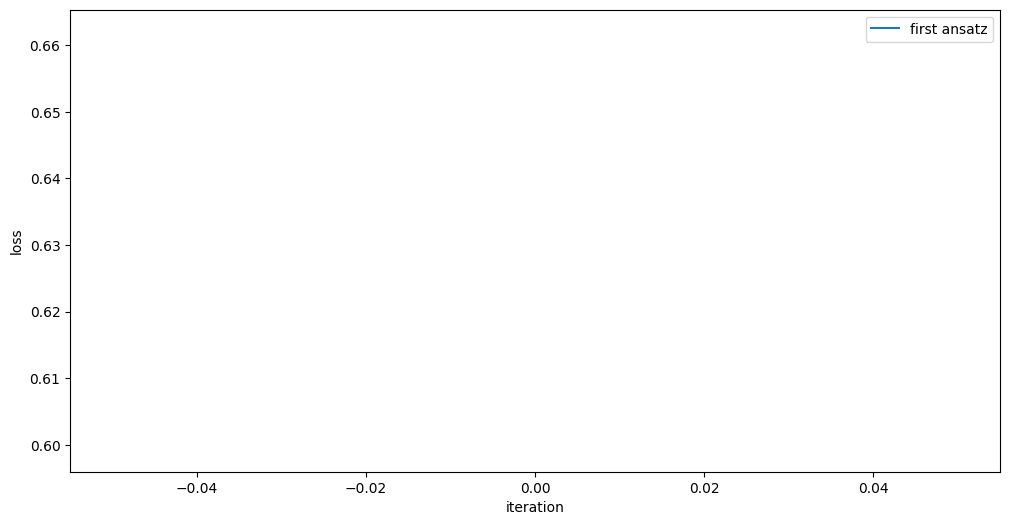

In [16]:
obj_func_vals_first = objective_func_vals
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(obj_func_vals_first, label="first ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

## Testing and accuracy

In [17]:
from sklearn.metrics import classification_report, precision_score, recall_score

def quantum_sweep(defect_rates, train_images_noise, circuit, weight_params,
                  estimator, observable, threshold=1.5,
                  n_test=200, size=4, seed=42):
    """
    Runs the trained quantum model across multiple defect rates.
    Returns lists of precision and recall on defects.
    """
    # reference distribution is fixed — compute once
    noise_preds = forward(circuit, train_images_noise, weight_params, estimator, observable)
    mu  = np.mean(noise_preds)
    std = np.std(noise_preds)
    print(f"Noise reference — mu: {mu:.4f}, std: {std:.4f}\n")

    quantum_precision = []
    quantum_recall    = []

    for rate in defect_rates:
        # generate test set at this defect rate
        test_images_raw, test_labels = generate_dataset(
            n_samples=n_test, size=size, defect_rate=rate, seed=seed)
        test_images_flat = np.array([img.flatten() * np.pi for img in test_images_raw])

        # forward pass
        all_preds = forward(circuit, test_images_flat, weight_params, estimator, observable)

        # threshold
        pred_labels = np.where(np.abs(all_preds - mu) > threshold * std, 1, -1)

        # metrics
        prec = precision_score(test_labels, pred_labels, pos_label=1, zero_division=0)
        rec  = recall_score(test_labels, pred_labels, pos_label=1, zero_division=0)
        quantum_precision.append(prec)
        quantum_recall.append(rec)

        print(f"=== Defect rate: {rate:.0%} ===")
        print(classification_report(test_labels, pred_labels,
                                    target_names=["noise", "defect"],
                                    zero_division=0))

    return quantum_precision, quantum_recall



In [18]:
# ── run it ────────────────────────────────────────────────────────────────────
defect_rates = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

quantum_precision, quantum_recall = quantum_sweep(
    defect_rates       = defect_rates,
    train_images_noise = train_images_noise,
    circuit            = circuit,
    weight_params      = weight_params,
    estimator          = estimator,
    observable         = observable,
    threshold          = 1.0,
    n_test             = 200,
    size               = 4,
    seed               = 42
)

print(quantum_precision, quantum_recall)

Noise reference — mu: -0.2424, std: 0.2381

=== Defect rate: 5% ===
              precision    recall  f1-score   support

       noise       0.97      0.73      0.83       190
      defect       0.10      0.60      0.18        10

    accuracy                           0.72       200
   macro avg       0.54      0.66      0.50       200
weighted avg       0.93      0.72      0.80       200

=== Defect rate: 10% ===
              precision    recall  f1-score   support

       noise       0.92      0.67      0.77       180
      defect       0.13      0.45      0.20        20

    accuracy                           0.65       200
   macro avg       0.52      0.56      0.49       200
weighted avg       0.84      0.65      0.71       200

=== Defect rate: 15% ===
              precision    recall  f1-score   support

       noise       0.88      0.72      0.80       170
      defect       0.23      0.47      0.31        30

    accuracy                           0.69       200
   macro a

## Classical solution

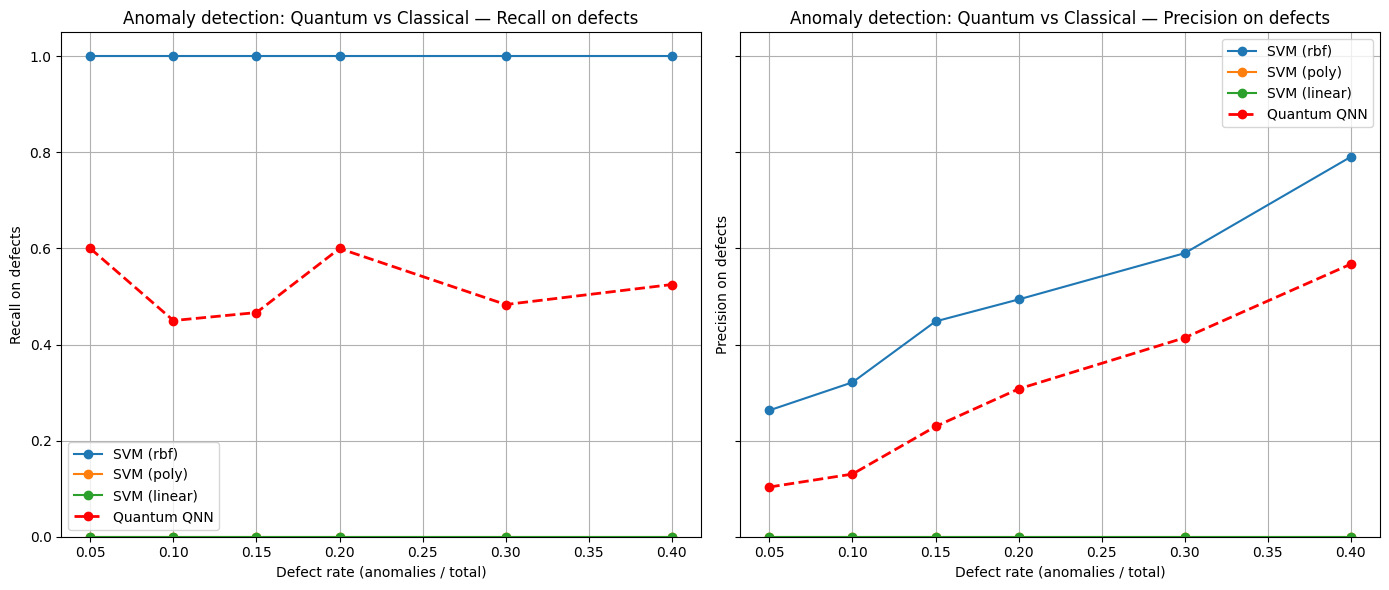

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.metrics import recall_score, precision_score
import matplotlib.pyplot as plt

defect_rates = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]

recall_results    = {"rbf": [], "poly": [], "linear": []}
precision_results = {"rbf": [], "poly": [], "linear": []}

for rate in defect_rates:
    images, labels = generate_dataset(n_samples=1000, defect_rate=rate, seed=7)

    train_imgs, test_imgs, train_lbls, test_lbls = train_test_split(
        images, labels, test_size=0.2, random_state=246)

    train_flat = np.array([img.flatten() for img in train_imgs])
    test_flat  = np.array([img.flatten() for img in test_imgs])

    noise_train = np.array([img for img, lbl in zip(train_flat, train_lbls) if lbl == -1])

    test_lbls_sklearn = np.where(np.array(test_lbls) == 1, -1, 1)

    for kernel in ["rbf", "poly", "linear"]:
        clf = OneClassSVM(kernel=kernel, nu=0.05)
        clf.fit(noise_train)
        preds = clf.predict(test_flat)
        recall_results[kernel].append(recall_score(test_lbls_sklearn, preds, pos_label=-1, zero_division=0))
        precision_results[kernel].append(precision_score(test_lbls_sklearn, preds, pos_label=-1, zero_division=0))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for kernel in ["rbf", "poly", "linear"]:
    ax1.plot(defect_rates, recall_results[kernel],    marker="o", label=f"SVM ({kernel})")
    ax2.plot(defect_rates, precision_results[kernel], marker="o", label=f"SVM ({kernel})")

ax1.plot(defect_rates, quantum_recall,    marker="o", linestyle="--", linewidth=2, color="red", label="Quantum QNN")
ax2.plot(defect_rates, quantum_precision, marker="o", linestyle="--", linewidth=2, color="red", label="Quantum QNN")

for ax, title in [(ax1, "Recall on defects"), (ax2, "Precision on defects")]:
    ax.set_xlabel("Defect rate (anomalies / total)")
    ax.set_ylabel(title)
    ax.set_title(f"Anomaly detection: Quantum vs Classical — {title}")
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

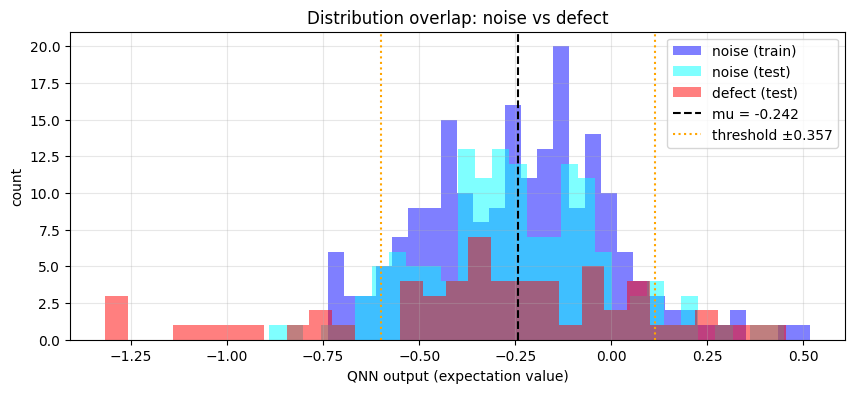

Noise train — mu: -0.2424, std: 0.2381
Noise test  — mean: -0.2501, std: 0.2360
Defect test — mean: -0.3212, std: 0.4053


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# get predictions for both classes on a fixed test set
test_images_raw, test_labels_arr = generate_dataset(n_samples=200, size=4, defect_rate=0.30, seed=42)
test_flat = np.array([img.flatten() * np.pi for img in test_images_raw])

all_preds   = forward(circuit, test_flat, weight_params, estimator, observable)
noise_preds = forward(circuit, train_images_noise, weight_params, estimator, observable)

mu  = np.mean(noise_preds)
std = np.std(noise_preds)

noise_test_preds  = all_preds[np.array(test_labels_arr) == -1]
defect_test_preds = all_preds[np.array(test_labels_arr) ==  1]

plt.figure(figsize=(10, 4))
plt.hist(noise_preds,       bins=30, alpha=0.5, color="blue",   label="noise (train)")
plt.hist(noise_test_preds,  bins=30, alpha=0.5, color="cyan",   label="noise (test)")
plt.hist(defect_test_preds, bins=30, alpha=0.5, color="red",    label="defect (test)")

# threshold lines
plt.axvline(mu,                     color="black",  linestyle="--", label=f"mu = {mu:.3f}")
plt.axvline(mu + 1.5*std,           color="orange", linestyle=":",  label=f"threshold ±{1.5*std:.3f}")
plt.axvline(mu - 1.5*std,           color="orange", linestyle=":")

plt.xlabel("QNN output (expectation value)")
plt.ylabel("count")
plt.title("Distribution overlap: noise vs defect")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Noise train — mu: {mu:.4f}, std: {std:.4f}")
print(f"Noise test  — mean: {noise_test_preds.mean():.4f}, std: {noise_test_preds.std():.4f}")
print(f"Defect test — mean: {defect_test_preds.mean():.4f}, std: {defect_test_preds.std():.4f}")